# NER / PII Detection: CRF vs BiLSTM-CRF vs spaCy vs DeBERTa

Benchmark four classical and neural NER models on the WikiANN English dataset.

| Model | Approach |
|---|---|
| CRF | Hand-crafted features + Conditional Random Field |
| BiLSTM-CRF | Bidirectional LSTM + CRF (PyTorch, GPU) |
| spaCy | spaCy v3 blank English NER |
| DeBERTa | `microsoft/deberta-v3-base` fine-tuned (GPU) |

**GPU:** RTX 5070 (Blackwell) — requires CUDA 12.8 + PyTorch ≥ 2.6

## Cell 1 — Installation
Run once; restart kernel afterwards.

## Cell 2 — Imports & GPU Setup

In [1]:
import json, os, time, random, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 130

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    get_linear_schedule_with_warmup
)

import sklearn_crfsuite
from seqeval.metrics import (
    classification_report, precision_score, recall_score, f1_score
)

import spacy
from spacy.tokens import Doc, Span
from spacy.training import Example
from spacy.util import minibatch, compounding

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'CUDA   : {torch.version.cuda}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
GPU    : NVIDIA GeForce RTX 5070
CUDA   : 12.8
VRAM   : 12.8 GB


## Cell 3 — Data Loading
Update `DATA_DIR` if the `.jsonl` files are in a different folder.

In [2]:
# ── Update this path if needed ───────────────────────────────────────────────
DATA_DIR = Path('D:/NER/data/processed/wikiann')

def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

train_data = load_jsonl(DATA_DIR / 'wikiann_en_train.jsonl')
val_data   = load_jsonl(DATA_DIR / 'wikiann_en_validation.jsonl')
test_data  = load_jsonl(DATA_DIR / 'wikiann_en_test.jsonl')

print(f'Train : {len(train_data):,} sentences')
print(f'Val   : {len(val_data):,} sentences')
print(f'Test  : {len(test_data):,} sentences')
print(f'\nExample sentence:')
print('  Tokens :', train_data[2]['tokens'])
print('  Tags   :', train_data[2]['ner_tags'])

Train : 20,000 sentences
Val   : 10,000 sentences
Test  : 10,000 sentences

Example sentence:
  Tokens : ['Karl', 'Ove', 'Knausgård', '(', 'born', '1968', ')']
  Tags   : ['B-PER', 'I-PER', 'I-PER', 'O', 'O', 'O', 'O']


## Cell 4 — Data Exploration

In [3]:
all_tags = [t for s in train_data for t in s['ner_tags']]
tag_counts = Counter(all_tags)
print('Label distribution in training set:')
for tag in sorted(tag_counts):
    print(f'  {tag:<8} {tag_counts[tag]:>7,}')

# Derived label sets
ALL_LABELS  = sorted({t for s in train_data for t in s['ner_tags']})
label2idx   = {lbl: i for i, lbl in enumerate(ALL_LABELS)}
idx2label   = {i: lbl for lbl, i in label2idx.items()}
NUM_LABELS  = len(ALL_LABELS)
print(f'\nAll labels ({NUM_LABELS}):', ALL_LABELS)

# Sequence length distribution
lengths = [len(s['tokens']) for s in train_data]
print(f'\nSeq length — mean: {np.mean(lengths):.1f}  '
      f'max: {max(lengths)}  p95: {np.percentile(lengths, 95):.0f}')

Label distribution in training set:
  B-LOC      9,422
  B-ORG      9,345
  B-PER      9,164
  I-LOC     23,226
  I-ORG     13,177
  I-PER     14,698
  O         81,362

All labels (7): ['B-LOC', 'B-ORG', 'B-PER', 'I-LOC', 'I-ORG', 'I-PER', 'O']

Seq length — mean: 8.0  max: 439  p95: 19


## Cell 5 — Shared Evaluation Utility

In [4]:
# Store results from all models
results = {}

def evaluate_model(true_seqs, pred_seqs, model_name):
    """Print seqeval report and return dict of overall scores."""
    p = precision_score(true_seqs, pred_seqs)
    r = recall_score(true_seqs, pred_seqs)
    f = f1_score(true_seqs, pred_seqs)
    print(f"\n{'='*62}")
    print(f'  {model_name}')
    print(f"\n{'='*62}")
    print(classification_report(true_seqs, pred_seqs, digits=4))
    return {'Precision': round(p,4), 'Recall': round(r,4), 'F1': round(f,4)}

print('Utility function `evaluate_model` ready.')

Utility function `evaluate_model` ready.


---
## Model 1 — CRF (Conditional Random Field)
Uses **hand-crafted lexical features**: lowercased form, character n-grams, shape flags,
context window ±2.

### Cell 6 — CRF Feature Engineering

In [5]:
def word2features(sent, i):
    word = sent[i]
    feat = {
        'bias'             : 1.0,
        'word.lower'       : word.lower(),
        'word[-3:]'        : word[-3:],
        'word[-2:]'        : word[-2:],
        'word[:3]'         : word[:3],
        'word[:2]'         : word[:2],
        'word.isupper'     : word.isupper(),
        'word.istitle'     : word.istitle(),
        'word.isdigit'     : word.isdigit(),
        'word.has_digit'   : any(c.isdigit() for c in word),
        'word.has_hyphen'  : '-' in word,
        'word.has_dot'     : '.' in word,
        'word.len'         : min(len(word), 20),
    }
    if i > 0:
        w = sent[i-1]
        feat.update({'-1:lower': w.lower(), '-1:istitle': w.istitle(),
                     '-1:isupper': w.isupper()})
    else:
        feat['BOS'] = True
    if i < len(sent)-1:
        w = sent[i+1]
        feat.update({'+1:lower': w.lower(), '+1:istitle': w.istitle(),
                     '+1:isupper': w.isupper()})
    else:
        feat['EOS'] = True
    if i > 1:
        w = sent[i-2]
        feat.update({'-2:lower': w.lower(), '-2:istitle': w.istitle()})
    if i < len(sent)-2:
        w = sent[i+2]
        feat.update({'+2:lower': w.lower(), '+2:istitle': w.istitle()})
    return feat

def sent2features(tokens): return [word2features(tokens, i) for i in range(len(tokens))]
def sent2labels(sample):   return sample['ner_tags']

print('Extracting CRF features...')
t0 = time.time()
X_train = [sent2features(s['tokens']) for s in train_data]
y_train = [sent2labels(s)             for s in train_data]
X_val   = [sent2features(s['tokens']) for s in val_data]
y_val   = [sent2labels(s)             for s in val_data]
X_test  = [sent2features(s['tokens']) for s in test_data]
y_test  = [sent2labels(s)             for s in test_data]
print(f'Features ready in {time.time()-t0:.1f}s')

Extracting CRF features...
Features ready in 1.1s


### Cell 7 — CRF Training

In [6]:
t0 = time.time()
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.05,
    c2=0.05,
    max_iterations=150,
    all_possible_transitions=True
)
crf.fit(X_train, y_train)
print(f'CRF trained in {time.time()-t0:.1f}s')

CRF trained in 30.7s


### Cell 8 — CRF Evaluation

In [7]:
y_pred_crf = crf.predict(X_test)
results['CRF'] = evaluate_model(y_test, y_pred_crf, 'CRF')


  CRF

              precision    recall  f1-score   support

         LOC     0.6605    0.5732    0.6138      4745
         ORG     0.7283    0.7421    0.7352      4657
         PER     0.8039    0.8244    0.8140      4556

   micro avg     0.7338    0.7116    0.7225     13958
   macro avg     0.7309    0.7133    0.7210     13958
weighted avg     0.7300    0.7116    0.7196     13958



---
## Model 2 — BiLSTM-CRF
Two-layer bidirectional LSTM feeding into a learnable CRF decoding layer. Runs on GPU.

### Cell 9 — Vocabulary & CRF Layer

In [8]:
# ── Build vocabulary ─────────────────────────────────────────────────────────
counter = Counter(tok for s in train_data for tok in s['tokens'])
word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, cnt in counter.items():
    if cnt >= 2:
        word2idx[word] = len(word2idx)
VOCAB_SIZE = len(word2idx)
print(f'Vocabulary size: {VOCAB_SIZE:,}')

# ── CRF Layer ────────────────────────────────────────────────────────────────
class CRFLayer(nn.Module):
    """Trainable linear-chain CRF with Viterbi decoding."""
    def __init__(self, num_tags):
        super().__init__()
        self.num_tags = num_tags
        # transitions[to, from]
        self.transitions    = nn.Parameter(torch.randn(num_tags, num_tags) * 0.1)
        self.start_trans    = nn.Parameter(torch.randn(num_tags) * 0.1)
        self.end_trans      = nn.Parameter(torch.randn(num_tags) * 0.1)

    def _log_sum_exp(self, x, dim):
        m, _ = x.max(dim, keepdim=True)
        return (x - m).exp().sum(dim, keepdim=True).log().squeeze(dim) + m.squeeze(dim)

    def _partition(self, emissions, mask):
        # emissions: (B, T, C)  mask: (B, T)
        B, T, C = emissions.shape
        alpha = self.start_trans + emissions[:, 0]           # (B, C)
        for t in range(1, T):
            # score[b, to, from] = alpha[b, from] + trans[to, from] + emit[b, t, to]
            score = (alpha.unsqueeze(1)                       # (B,  1, C)
                     + self.transitions                       # (C,  C)
                     + emissions[:, t].unsqueeze(2))          # (B,  C, 1)
            new_alpha = self._log_sum_exp(score, dim=2)       # (B,  C)
            m = mask[:, t].unsqueeze(1)
            alpha = new_alpha * m + alpha * (1 - m)
        alpha = alpha + self.end_trans
        return self._log_sum_exp(alpha, dim=1)                # (B,)

    def _seq_score(self, emissions, tags, mask):
        B, T = tags.shape
        score = self.start_trans[tags[:, 0]] + \
                emissions[:, 0].gather(1, tags[:, 0].unsqueeze(1)).squeeze(1)
        for t in range(1, T):
            tr  = self.transitions[tags[:, t], tags[:, t-1]]
            em  = emissions[:, t].gather(1, tags[:, t].unsqueeze(1)).squeeze(1)
            score += (tr + em) * mask[:, t]
        last_idx  = mask.long().sum(1) - 1
        last_tags = tags.gather(1, last_idx.unsqueeze(1)).squeeze(1)
        score    += self.end_trans[last_tags]
        return score

    def forward(self, emissions, tags, mask):
        return -(self._seq_score(emissions, tags, mask)
                 - self._partition(emissions, mask)).mean()

    def decode(self, emissions, mask):
        B, T, C = emissions.shape
        viterbi  = self.start_trans + emissions[:, 0]  # (B, C)
        bptrs    = []
        for t in range(1, T):
            score = viterbi.unsqueeze(1) + self.transitions  # (B, C, C)
            best_scores, best_tags = score.max(2)            # (B, C)
            bptrs.append(best_tags)
            new_v = best_scores + emissions[:, t]
            m = mask[:, t].unsqueeze(1)
            viterbi = new_v * m + viterbi * (1 - m)
        viterbi += self.end_trans
        _, best_last = viterbi.max(1)      # (B,)
        path = [best_last]
        for bp in reversed(bptrs):
            best_last = bp.gather(1, best_last.unsqueeze(1)).squeeze(1)
            path.insert(0, best_last)
        return torch.stack(path, dim=1)    # (B, T)

print('CRFLayer defined.')

Vocabulary size: 9,873
CRFLayer defined.


### Cell 10 — BiLSTM-CRF Model Architecture

In [9]:
class BiLSTMCRF(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_tags, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)
        self.lstm      = nn.LSTM(emb_dim, hidden_dim // 2, num_layers=2,
                                 bidirectional=True, batch_first=True,
                                 dropout=dropout)
        self.fc        = nn.Linear(hidden_dim, num_tags)
        self.crf       = CRFLayer(num_tags)

    def _emit(self, x):
        e, _ = self.lstm(self.dropout(self.embedding(x)))
        return self.fc(self.dropout(e))

    def forward(self, x, tags, mask):
        return self.crf(self._emit(x), tags, mask)

    def predict(self, x, mask):
        self.eval()
        with torch.no_grad():
            return self.crf.decode(self._emit(x), mask)

bilstm = BiLSTMCRF(VOCAB_SIZE, emb_dim=128, hidden_dim=256,
                   num_tags=NUM_LABELS).to(device)
params = sum(p.numel() for p in bilstm.parameters() if p.requires_grad)
print(f'BiLSTM-CRF params: {params:,}')

BiLSTM-CRF params: 1,925,062


### Cell 11 — Dataset & DataLoaders

In [10]:
MAX_LEN_LSTM = 128

class NERDataset(Dataset):
    def __init__(self, data, max_len=MAX_LEN_LSTM):
        self.samples = []
        for s in data:
            toks = s['tokens'][:max_len]
            tags = s['ner_tags'][:max_len]
            self.samples.append((
                [word2idx.get(t, 1) for t in toks],
                [label2idx[g] for g in tags]
            ))
    def __len__(self):         return len(self.samples)
    def __getitem__(self, i):  return self.samples[i]

def collate(batch):
    tok_seqs, tag_seqs = zip(*batch)
    L  = max(len(s) for s in tok_seqs)
    B  = len(tok_seqs)
    tok_pad = torch.zeros(B, L, dtype=torch.long)
    tag_pad = torch.zeros(B, L, dtype=torch.long)
    mask    = torch.zeros(B, L)
    for i, (tok, tag) in enumerate(zip(tok_seqs, tag_seqs)):
        n = len(tok)
        tok_pad[i, :n] = torch.tensor(tok)
        tag_pad[i, :n] = torch.tensor(tag)
        mask[i, :n]    = 1.0
    return tok_pad, tag_pad, mask

train_ds = NERDataset(train_data)
val_ds   = NERDataset(val_data)
test_ds  = NERDataset(test_data)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True,  collate_fn=collate)
val_dl   = DataLoader(val_ds,   batch_size=256, collate_fn=collate)
test_dl  = DataLoader(test_ds,  batch_size=256, collate_fn=collate)
print(f'Batches — train: {len(train_dl)}  val: {len(val_dl)}  test: {len(test_dl)}')

Batches — train: 157  val: 40  test: 40


### Cell 12 — BiLSTM-CRF Training

In [11]:
def eval_bilstm(model, loader):
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for toks, tags, mask in loader:
            toks, tags, mask = toks.to(device), tags.to(device), mask.to(device)
            preds = model.predict(toks, mask)
            for i in range(toks.size(0)):
                L = int(mask[i].sum().item())
                all_true.append([idx2label[t.item()] for t in tags[i, :L]])
                all_pred.append([idx2label[t.item()] for t in preds[i, :L]])
    return all_true, all_pred, f1_score(all_true, all_pred)

opt_lstm    = AdamW(bilstm.parameters(), lr=1e-3, weight_decay=1e-4)
N_EPO_LSTM  = 20
best_f1_lstm = 0.0

print(f'Training BiLSTM-CRF for {N_EPO_LSTM} epochs on {device}...')
t0 = time.time()
for epoch in range(1, N_EPO_LSTM + 1):
    bilstm.train()
    total_loss = 0.0
    for toks, tags, mask in train_dl:
        toks, tags, mask = toks.to(device), tags.to(device), mask.to(device)
        opt_lstm.zero_grad()
        loss = bilstm(toks, tags, mask)
        loss.backward()
        nn.utils.clip_grad_norm_(bilstm.parameters(), 5.0)
        opt_lstm.step()
        total_loss += loss.item()
    _, _, val_f1 = eval_bilstm(bilstm, val_dl)
    avg_loss = total_loss / len(train_dl)
    print(f'Epoch {epoch:02d}/{N_EPO_LSTM}  loss={avg_loss:.4f}  val_F1={val_f1:.4f}')
    if val_f1 > best_f1_lstm:
        best_f1_lstm = val_f1
        torch.save(bilstm.state_dict(), 'best_bilstm_crf.pt')

print(f'\nDone in {time.time()-t0:.0f}s  best_val_F1={best_f1_lstm:.4f}')

Training BiLSTM-CRF for 20 epochs on cuda...
Epoch 01/20  loss=9.2093  val_F1=0.4340
Epoch 02/20  loss=5.8910  val_F1=0.5315
Epoch 03/20  loss=4.7841  val_F1=0.5702
Epoch 04/20  loss=4.1321  val_F1=0.5958
Epoch 05/20  loss=3.6447  val_F1=0.6188
Epoch 06/20  loss=3.3083  val_F1=0.6320
Epoch 07/20  loss=2.9870  val_F1=0.6457
Epoch 08/20  loss=2.7735  val_F1=0.6585
Epoch 09/20  loss=2.5822  val_F1=0.6587
Epoch 10/20  loss=2.4112  val_F1=0.6681
Epoch 11/20  loss=2.2534  val_F1=0.6753
Epoch 12/20  loss=2.1333  val_F1=0.6780
Epoch 13/20  loss=2.0446  val_F1=0.6896
Epoch 14/20  loss=1.9348  val_F1=0.6921
Epoch 15/20  loss=1.8610  val_F1=0.7002
Epoch 16/20  loss=1.7824  val_F1=0.6921
Epoch 17/20  loss=1.7240  val_F1=0.6995
Epoch 18/20  loss=1.6602  val_F1=0.7005
Epoch 19/20  loss=1.5761  val_F1=0.7051
Epoch 20/20  loss=1.5457  val_F1=0.7027

Done in 178s  best_val_F1=0.7051


### Cell 13 — BiLSTM-CRF Evaluation

In [12]:
bilstm.load_state_dict(torch.load('best_bilstm_crf.pt', map_location=device))
y_true_lstm, y_pred_lstm, _ = eval_bilstm(bilstm, test_dl)
results['BiLSTM-CRF'] = evaluate_model(y_true_lstm, y_pred_lstm, 'BiLSTM-CRF')


  BiLSTM-CRF

              precision    recall  f1-score   support

         LOC     0.6740    0.5583    0.6107      4745
         ORG     0.7234    0.7339    0.7286      4657
         PER     0.7651    0.7938    0.7792      4530

   micro avg     0.7235    0.6936    0.7082     13932
   macro avg     0.7208    0.6953    0.7062     13932
weighted avg     0.7201    0.6936    0.7049     13932



---
## Model 3 — spaCy NER
Uses spaCy v3 with a blank English model. Trained directly on pre-tokenized data
via `Doc` objects to avoid re-tokenization drift.

### Cell 14 — spaCy Data Preparation

In [13]:
def make_spacy_example(nlp, tokens, ner_tags):
    """Create a spaCy Example from pre-tokenized tokens + BIO tags."""
    ref_doc = Doc(nlp.vocab, words=tokens)
    ents, i = [], 0
    while i < len(ner_tags):
        tag = ner_tags[i]
        if tag.startswith('B-'):
            label = tag[2:]
            j = i + 1
            while j < len(ner_tags) and ner_tags[j].startswith('I-'):
                j += 1
            try:
                ents.append(Span(ref_doc, i, j, label=label))
            except Exception:
                pass
            i = j
        else:
            i += 1
    try:
        ref_doc.ents = ents
    except Exception:
        from spacy.util import filter_spans
        ref_doc.ents = filter_spans(ents)
    pred_doc = Doc(nlp.vocab, words=tokens)   # same tokenization
    return Example(pred_doc, ref_doc)

# ── Build blank model ────────────────────────────────────────────────────────
nlp_spacy = spacy.blank('en')
ner_pipe  = nlp_spacy.add_pipe('ner')

entity_labels = {t[2:] for s in train_data for t in s['ner_tags'] if t != 'O'}
for lbl in entity_labels:
    ner_pipe.add_label(lbl)
print(f'Entity labels: {entity_labels}')

# Build training examples
SPACY_TRAIN_SIZE = 10000   # increase to 20000 for best accuracy (slower)
print(f'Building {SPACY_TRAIN_SIZE} spaCy training examples...')
t0 = time.time()
spacy_train_examples = [
    make_spacy_example(nlp_spacy, s['tokens'], s['ner_tags'])
    for s in train_data[:SPACY_TRAIN_SIZE]
]
print(f'Done in {time.time()-t0:.1f}s')

Entity labels: {'ORG', 'LOC', 'PER'}
Building 10000 spaCy training examples...
Done in 0.7s


### Cell 15 — spaCy Training

In [14]:
N_EPO_SPACY = 15
opt_spacy   = nlp_spacy.initialize()
best_f1_spacy = 0.0

print(f'Training spaCy NER for {N_EPO_SPACY} epochs...')
t0 = time.time()
for epoch in range(1, N_EPO_SPACY + 1):
    random.shuffle(spacy_train_examples)
    losses = {}
    batches = minibatch(spacy_train_examples, size=compounding(4.0, 64.0, 1.001))
    for batch in batches:
        nlp_spacy.update(batch, sgd=opt_spacy, drop=0.3, losses=losses)
    print(f'Epoch {epoch:02d}/{N_EPO_SPACY}  NER loss={losses.get("ner", 0):.2f}')
print(f'\nDone in {time.time()-t0:.0f}s')

Training spaCy NER for 15 epochs...
Epoch 01/15  NER loss=20486.41
Epoch 02/15  NER loss=16707.31
Epoch 03/15  NER loss=13824.43
Epoch 04/15  NER loss=12462.56
Epoch 05/15  NER loss=11568.61
Epoch 06/15  NER loss=10904.96
Epoch 07/15  NER loss=10343.12
Epoch 08/15  NER loss=9700.53
Epoch 09/15  NER loss=9291.62
Epoch 10/15  NER loss=8497.68
Epoch 11/15  NER loss=8344.85
Epoch 12/15  NER loss=7971.14
Epoch 13/15  NER loss=7635.40
Epoch 14/15  NER loss=7298.91
Epoch 15/15  NER loss=6887.59

Done in 494s


### Cell 16 — spaCy Evaluation

In [15]:
def predict_spacy(nlp, data):
    all_true, all_pred = [], []
    for sample in data:
        tokens   = sample['tokens']
        true_tags = sample['ner_tags']
        # Run NER on a pre-tokenized Doc (avoids re-tokenization issues)
        doc = Doc(nlp.vocab, words=tokens)
        for _, component in nlp.pipeline:
            doc = component(doc)
        # Reconstruct BIO from predicted ents
        pred_tags = ['O'] * len(tokens)
        for ent in doc.ents:
            pred_tags[ent.start] = f'B-{ent.label_}'
            for t in range(ent.start + 1, ent.end):
                pred_tags[t] = f'I-{ent.label_}'
        all_true.append(true_tags)
        all_pred.append(pred_tags)
    return all_true, all_pred

y_true_spacy, y_pred_spacy = predict_spacy(nlp_spacy, test_data)
results['spaCy'] = evaluate_model(y_true_spacy, y_pred_spacy, 'spaCy')


  spaCy

              precision    recall  f1-score   support

         LOC     0.5538    0.4976    0.5242      4745
         ORG     0.7129    0.6388    0.6738      4657
         PER     0.6839    0.7902    0.7332      4556

   micro avg     0.6523    0.6402    0.6462     13958
   macro avg     0.6502    0.6422    0.6437     13958
weighted avg     0.6494    0.6402    0.6423     13958



---
## Model 4 — DeBERTa (`microsoft/deberta-v3-base`)
Fine-tunes a pre-trained DeBERTa v3 model for token classification.
Uses mixed-precision (`torch.cuda.amp`) for RTX 5070 speed.

### Cell 17 — Tokenisation & Dataset

In [16]:
MODEL_NAME  = 'microsoft/deberta-v3-base'
MAX_LEN_DB  = 128

print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align(sample, max_length=MAX_LEN_DB):
    tokens = sample['tokens']
    tags   = sample['ner_tags']
    enc = tokenizer(
        tokens, is_split_into_words=True,
        max_length=max_length, truncation=True, padding='max_length'
    )
    word_ids  = enc.word_ids()
    label_ids = []
    prev_wid  = None
    for wid in word_ids:
        if wid is None:
            label_ids.append(-100)
        elif wid != prev_wid:
            label_ids.append(label2idx[tags[wid]])
        else:
            label_ids.append(-100)   # subword — ignore in loss
        prev_wid = wid
    out = {'input_ids': enc['input_ids'], 'attention_mask': enc['attention_mask'],
           'labels': label_ids}
    if 'token_type_ids' in enc:
        out['token_type_ids'] = enc['token_type_ids']
    return out

class TokenDataset(Dataset):
    def __init__(self, data):
        self.samples = [tokenize_and_align(s) for s in data]
    def __len__(self):        return len(self.samples)
    def __getitem__(self, i): return {k: torch.tensor(v) for k, v in self.samples[i].items()}

print('Building DeBERTa datasets (this may take ~1–2 min)...')
t0 = time.time()
db_train_ds = TokenDataset(train_data)
db_val_ds   = TokenDataset(val_data)
db_test_ds  = TokenDataset(test_data)
print(f'Done in {time.time()-t0:.0f}s')

db_train_dl = DataLoader(db_train_ds, batch_size=32, shuffle=True)
db_val_dl   = DataLoader(db_val_ds,   batch_size=64)
db_test_dl  = DataLoader(db_test_ds,  batch_size=64)
print(f'Batches — train: {len(db_train_dl)}  val: {len(db_val_dl)}  test: {len(db_test_dl)}')

Loading tokenizer: microsoft/deberta-v3-base
Building DeBERTa datasets (this may take ~1–2 min)...
Done in 8s
Batches — train: 625  val: 157  test: 157


### Cell 18 — DeBERTa Model & Training

In [17]:
print(f'Loading model: {MODEL_NAME}')
deberta = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS,
    id2label=idx2label, label2id=label2idx,
    ignore_mismatched_sizes=True
).to(device)
params_db = sum(p.numel() for p in deberta.parameters() if p.requires_grad)
print(f'DeBERTa params: {params_db/1e6:.1f}M')

N_EPO_DB     = 5
TOTAL_STEPS  = len(db_train_dl) * N_EPO_DB
WARMUP_STEPS = TOTAL_STEPS // 10

opt_db    = AdamW(deberta.parameters(), lr=2e-5, weight_decay=0.01)
sched_db  = get_linear_schedule_with_warmup(opt_db, WARMUP_STEPS, TOTAL_STEPS)
scaler    = GradScaler()   # mixed-precision for RTX 5070

def eval_deberta(model, loader):
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            amask = batch['attention_mask'].to(device)
            lbls  = batch['labels'].to(device)
            with autocast():
                logits = model(input_ids=ids, attention_mask=amask).logits
            preds = logits.argmax(-1)
            for i in range(ids.size(0)):
                true_seq, pred_seq = [], []
                for j in range(ids.size(1)):
                    if lbls[i, j].item() != -100:
                        true_seq.append(idx2label[lbls[i, j].item()])
                        pred_seq.append(idx2label[preds[i, j].item()])
                all_true.append(true_seq)
                all_pred.append(pred_seq)
    return all_true, all_pred, f1_score(all_true, all_pred)

best_f1_db = 0.0
print(f'Training DeBERTa for {N_EPO_DB} epochs on {device}...')
t0 = time.time()

for epoch in range(1, N_EPO_DB + 1):
    deberta.train()
    total_loss = 0.0
    for step, batch in enumerate(db_train_dl):
        ids   = batch['input_ids'].to(device)
        amask = batch['attention_mask'].to(device)
        lbls  = batch['labels'].to(device)
        opt_db.zero_grad()
        with autocast():
            loss = deberta(input_ids=ids, attention_mask=amask, labels=lbls).loss
        scaler.scale(loss).backward()
        scaler.unscale_(opt_db)
        nn.utils.clip_grad_norm_(deberta.parameters(), 1.0)
        scaler.step(opt_db)
        scaler.update()
        sched_db.step()
        total_loss += loss.item()
        if (step + 1) % 100 == 0:
            print(f'  [Epoch {epoch}] step {step+1}/{len(db_train_dl)}  '
                  f'loss={loss.item():.4f}')
    _, _, val_f1 = eval_deberta(deberta, db_val_dl)
    avg = total_loss / len(db_train_dl)
    print(f'Epoch {epoch:02d}/{N_EPO_DB}  avg_loss={avg:.4f}  val_F1={val_f1:.4f}')
    if val_f1 > best_f1_db:
        best_f1_db = val_f1
        torch.save(deberta.state_dict(), 'best_deberta.pt')

print(f'\nDone in {time.time()-t0:.0f}s  best_val_F1={best_f1_db:.4f}')

Loading model: microsoft/deberta-v3-base


Some weights of DebertaV2ForTokenClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DeBERTa params: 183.8M
Training DeBERTa for 5 epochs on cuda...
  [Epoch 1] step 100/625  loss=0.8335
  [Epoch 1] step 200/625  loss=0.6283
  [Epoch 1] step 300/625  loss=0.5094
  [Epoch 1] step 400/625  loss=0.2826
  [Epoch 1] step 500/625  loss=0.3444
  [Epoch 1] step 600/625  loss=0.1584
Epoch 01/5  avg_loss=0.5566  val_F1=0.8071
  [Epoch 2] step 100/625  loss=0.1415
  [Epoch 2] step 200/625  loss=0.2267
  [Epoch 2] step 300/625  loss=0.2586
  [Epoch 2] step 400/625  loss=0.4501
  [Epoch 2] step 500/625  loss=0.1690
  [Epoch 2] step 600/625  loss=0.2649
Epoch 02/5  avg_loss=0.2305  val_F1=0.8291
  [Epoch 3] step 100/625  loss=0.2223
  [Epoch 3] step 200/625  loss=0.1797
  [Epoch 3] step 300/625  loss=0.1831
  [Epoch 3] step 400/625  loss=0.2212
  [Epoch 3] step 500/625  loss=0.2815
  [Epoch 3] step 600/625  loss=0.2229
Epoch 03/5  avg_loss=0.1781  val_F1=0.8407
  [Epoch 4] step 100/625  loss=0.1781
  [Epoch 4] step 200/625  loss=0.1828
  [Epoch 4] step 300/625  loss=0.1261
  [Epoch 

### Cell 19 — DeBERTa Evaluation

In [18]:
deberta.load_state_dict(torch.load('best_deberta.pt', map_location=device))
y_true_db, y_pred_db, _ = eval_deberta(deberta, db_test_dl)
results['DeBERTa'] = evaluate_model(y_true_db, y_pred_db, 'DeBERTa')


  DeBERTa

              precision    recall  f1-score   support

         LOC     0.7591    0.7810    0.7699      4745
         ORG     0.8423    0.8673    0.8546      4643
         PER     0.8966    0.9071    0.9018      4520

   micro avg     0.8312    0.8508    0.8409     13908
   macro avg     0.8327    0.8518    0.8421     13908
weighted avg     0.8316    0.8508    0.8411     13908



---
## Final Comparison
### Cell 20 — Summary Table & Chart


         FINAL RESULTS (micro-averaged)
            Precision  Recall     F1
Model                               
CRF            0.7338  0.7116 0.7225
BiLSTM-CRF     0.7235  0.6936 0.7082
spaCy          0.6523  0.6402 0.6462
DeBERTa        0.8312  0.8508 0.8409


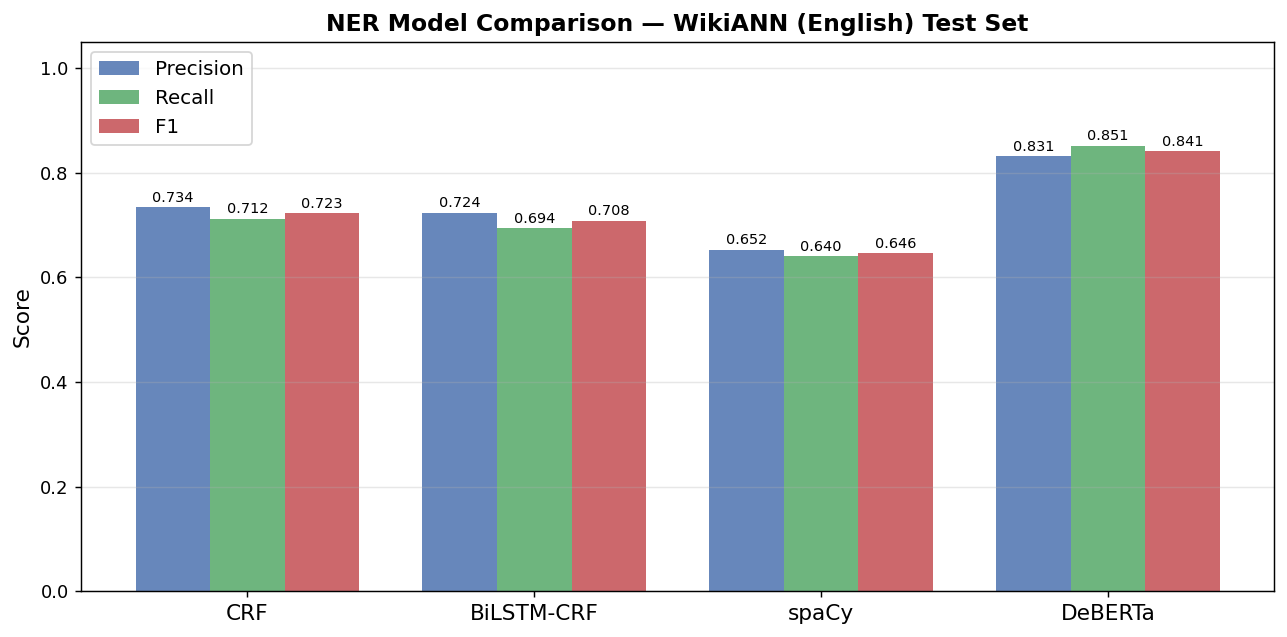

Chart saved to ner_model_comparison.png


In [19]:
df = pd.DataFrame(results).T
df.index.name = 'Model'
print('\n' + '='*50)
print('         FINAL RESULTS (micro-averaged)')
print('='*50)
print(df.to_string(float_format='{:.4f}'.format))
print('='*50)

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(df))
width = 0.26
colors = ['#4C72B0', '#55A868', '#C44E52']
for k, (col, color) in enumerate(zip(['Precision','Recall','F1'], colors)):
    bars = ax.bar(x + k*width, df[col], width, label=col, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(df.index, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('NER Model Comparison — WikiANN (English) Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ner_model_comparison.png', dpi=150)
plt.show()
print('Chart saved to ner_model_comparison.png')

### Cell 21 — Per-Entity Breakdown

In [20]:
print('\n--- CRF per-entity ---')
print(classification_report(y_test, y_pred_crf, digits=4))

print('\n--- BiLSTM-CRF per-entity ---')
print(classification_report(y_true_lstm, y_pred_lstm, digits=4))

print('\n--- spaCy per-entity ---')
print(classification_report(y_true_spacy, y_pred_spacy, digits=4))

print('\n--- DeBERTa per-entity ---')
print(classification_report(y_true_db, y_pred_db, digits=4))


--- CRF per-entity ---
              precision    recall  f1-score   support

         LOC     0.6605    0.5732    0.6138      4745
         ORG     0.7283    0.7421    0.7352      4657
         PER     0.8039    0.8244    0.8140      4556

   micro avg     0.7338    0.7116    0.7225     13958
   macro avg     0.7309    0.7133    0.7210     13958
weighted avg     0.7300    0.7116    0.7196     13958


--- BiLSTM-CRF per-entity ---
              precision    recall  f1-score   support

         LOC     0.6740    0.5583    0.6107      4745
         ORG     0.7234    0.7339    0.7286      4657
         PER     0.7651    0.7938    0.7792      4530

   micro avg     0.7235    0.6936    0.7082     13932
   macro avg     0.7208    0.6953    0.7062     13932
weighted avg     0.7201    0.6936    0.7049     13932


--- spaCy per-entity ---
              precision    recall  f1-score   support

         LOC     0.5538    0.4976    0.5242      4745
         ORG     0.7129    0.6388    0.6738     